# Projekt MAPB – Milestone 1: Zrozumienie zbioru danych (Cotton Candy)

Ten notebook realizuje pierwszy kamień milowy projektu z przedmiotu **Modelowanie i analiza procesów biznesowych** dla zbioru danych *Cotton Candy* (log zdarzeń z maszyny do waty cukrowej).

## Konfiguracja środowiska (venv + uv)

Aby uruchomić ten notebook lokalnie w oddzielnym środowisku Pythona:

1. W terminalu przejdź do katalogu projektu `MAPB`.
2. Utwórz środowisko wirtualne przy pomocy uv:
   - `uv venv .venv`
3. Aktywuj środowisko (PowerShell / VS Code terminal):
   - `.venv\Scripts\activate`
4. Zainstaluj wymagane pakiety:
   - `uv pip install -r requirements.txt`
5. W VS Code / Jupyter wybierz kernel Pythona ze środowiska `.venv` i uruchom wszystkie komórki notebooka.

In [6]:
# 1. Import bibliotek i konfiguracja środowiska

import os
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import yaml

# Ustawienia wyświetlania
pd.set_option("display.max_columns", 100)
pd.set_option("display.width", 160)

# Ścieżki
BASE_DIR = Path(r"c:/Users/dusza/Documents/Studia/7semestr/MAPB")
DATA_DIR = BASE_DIR / "cotton-candy"

print("Katalog bazowy:", BASE_DIR)
print("Dostępne batch-e:", sorted(p.name for p in DATA_DIR.iterdir() if p.is_dir()))


Katalog bazowy: c:\Users\dusza\Documents\Studia\7semestr\MAPB
Dostępne batch-e: ['batch-0', 'batch-1', 'batch-10', 'batch-11', 'batch-12', 'batch-13', 'batch-14', 'batch-15', 'batch-16', 'batch-17', 'batch-18', 'batch-19', 'batch-2', 'batch-20', 'batch-21', 'batch-22', 'batch-23', 'batch-3', 'batch-4', 'batch-5', 'batch-6', 'batch-7', 'batch-8', 'batch-9']


## 2. Wczytanie przykładowego logu zdarzeń z Cotton Candy

Na potrzeby Milestone 1 analizujemy jeden plik z logiem zdarzeń (format XES zapisany jako YAML) z jednego z batchy. W kolejnych kamieniach można rozszerzyć analizę na więcej plików.

In [7]:
# Funkcja pomocnicza do wczytania jednego pliku .xes.yaml i spłaszczenia eventów do DataFrame

from typing import List, Dict, Any


def load_xes_yaml(path: Path) -> pd.DataFrame:
    """Wczytuje plik XES zapisany jako YAML i zwraca DataFrame z eventami.

    Każdy blok `event:` po separatorze `---` staje się jednym wierszem w tabeli.
    Zagnieżdżone struktury trzymamy jako słowniki / listy (do dalszej analizy).
    """
    with path.open("r", encoding="utf-8") as f:
        docs = list(yaml.safe_load_all(f))

    # Pierwszy dokument to zwykle metadata logu (pole `log`)
    meta = docs[0].get("log", {}) if docs and isinstance(docs[0], dict) else {}

    events: List[Dict[str, Any]] = []
    for doc in docs[1:]:
        if not isinstance(doc, dict):
            continue
        ev = doc.get("event", {})
        if not ev:
            continue
        flat: Dict[str, Any] = {}
        for k, v in ev.items():
            # zamieniamy nietypowe klucze typu "concept:name" na przyjaźniejsze nazwy
            key = k.replace(":", "_")
            flat[key] = v
        # dodajemy informacje z meta (id instancji itp.)
        for k, v in meta.items():
            if isinstance(v, dict):
                for kk, vv in v.items():
                    flat[f"meta_{k}_{kk}"] = vv
            else:
                flat[f"meta_{k}"] = v
        events.append(flat)

    df = pd.json_normalize(events, sep="_")
    return df


# wybierzmy przykładowy plik z batch-0
example_file = next((p for p in (DATA_DIR / "batch-0").glob("*.xes.yaml")), None)
print("Przykładowy plik:", example_file)

df_events = load_xes_yaml(example_file)
df_events.head()

Przykładowy plik: c:\Users\dusza\Documents\Studia\7semestr\MAPB\cotton-candy\batch-0\028e282d-26a3-4ae8-909e-a033e6794cc8.xes.yaml


,concept_instance,id_id,cpee_activity,cpee_instance,lifecycle_transition,cpee_lifecycle_transition,cpee_state,time_timestamp,meta_namespaces_stream,meta_namespaces_ssn,meta_namespaces_sosa,meta_xes_creator,meta_xes_features,meta_extension_time,meta_extension_concept,meta_extension_id,meta_extension_lifecycle,meta_extension_cpee,meta_extension_stream,meta_trace_concept:name,meta_trace_cpee:name,meta_trace_cpee:instance,meta_global_trace_concept:name,meta_global_trace_cpee:name,meta_global_event_concept:instance,meta_global_event_concept:name,meta_global_event_concept:endpoint,meta_global_event_id:id,meta_global_event_cpee:uuid,meta_global_event_lifecycle:transition,meta_global_event_cpee:lifecycle:transition,meta_global_event_time:timestamp,data,cpee_description,cpee_change_uuid,concept_name,cpee_activity_uuid,concept_endpoint,data_CPEE-INSTANCE,data_CPEE-INSTANCE-URL,data_CPEE-INSTANCE-UUID,data_CPEE-BEHAVIOR
0,61168,external,external,028e282d-26a3-4ae8-909e-a033e6794cc8,unknown,state/change,ready,2025-07-28T01:44:28.602373+02:00,https://cpee.org/datastream/,http://www.w3.org/ns/ssn/,http://www.w3.org/ns/sosa/,cpee.org,nested-attributes,http://www.xes-standard.org/time.xesext,http://www.xes-standard.org/concept.xesext,http://www.xes-standard.org/identity.xesext,http://www.xes-standard.org/lifecycle.xesext,http://cpee.org/cpee.xesext,https://cpee.org/datastream/datastream.xesext,61168,Create 11 Cotton Candies,028e282d-26a3-4ae8-909e-a033e6794cc8,__NOTSPECIFIED__,__NOTSPECIFIED__,-1,__NOTSPECIFIED__,__NOTSPECIFIED__,__NOTSPECIFIED__,__NOTSPECIFIED__,complete,activity/calling,,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,61168,external,external,028e282d-26a3-4ae8-909e-a033e6794cc8,unknown,endpoints/change,NaN,2025-07-28T01:44:28.608118+02:00,https://cpee.org/datastream/,http://www.w3.org/ns/ssn/,http://www.w3.org/ns/sosa/,cpee.org,nested-attributes,http://www.xes-standard.org/time.xesext,http://www.xes-standard.org/concept.xesext,http://www.xes-standard.org/identity.xesext,http://www.xes-standard.org/lifecycle.xesext,http://cpee.org/cpee.xesext,https://cpee.org/datastream/datastream.xesext,61168,Create 11 Cotton Candies,028e282d-26a3-4ae8-909e-a033e6794cc8,__NOTSPECIFIED__,__NOTSPECIFIED__,-1,__NOTSPECIFIED__,__NOTSPECIFIED__,__NOTSPECIFIED__,__NOTSPECIFIED__,complete,activity/calling,,"[{'name': 'timeout', 'value': 'https://cpee.or...",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,61168,external,external,028e282d-26a3-4ae8-909e-a033e6794cc8,unknown,dataelements/change,NaN,2025-07-28T01:44:28.605931+02:00,https://cpee.org/datastream/,http://www.w3.org/ns/ssn/,http://www.w3.org/ns/sosa/,cpee.org,nested-attributes,http://www.xes-standard.org/time.xesext,http://www.xes-standard.org/concept.xesext,http://www.xes-standard.org/identity.xesext,http://www.xes-standard.org/lifecycle.xesext,http://cpee.org/cpee.xesext,https://cpee.org/datastream/datastream.xesext,61168,Create 11 Cotton Candies,028e282d-26a3-4ae8-909e-a033e6794cc8,__NOTSPECIFIED__,__NOTSPECIFIED__,-1,__NOTSPECIFIED__,__NOTSPECIFIED__,__NOTSPECIFIED__,__NOTSPECIFIED__,complete,activity/calling,,"[{'name': 'batch_number', 'value': 0}, {'name'...",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,61168,external,external,028e282d-26a3-4ae8-909e-a033e6794cc8,unknown,attributes/change,NaN,2025-07-28T01:44:28.610887+02:00,https://cpee.org/datastream/,http://www.w3.org/ns/ssn/,http://www.w3.org/ns/sosa/,cpee.org,nested-attributes,http://www.xes-standard.org/time.xesext,http://www.xes-standard.org/concept.xesext,http://www.xes-standard.org/identity.xesext,http://www.xes-standard.org/lifecycle.xesext,http://cpee.org/cpee.xesext,https://cpee.org/datastream/datastream.xesext,61168,Create 11 Cotton Candies,028e282d-26a3-4ae8-909e-a033e6794cc8,__NOTSPECIFIED__,__NOTSPECIFIED__,-1,__NOTSPECIFIED__,__NOTSPECIFIED__,__NOTSPECIFIED__,__NOTSPECIFIED__,complete,activity/calling,,"[{'name': 'guarded', 'value': 'none'}, {'name'...",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,61168,external,external,028e282d-26a3-4ae8-909e-a

## 3. Identyfikacja kluczowych atrybutów logu zdarzeń

W tej sekcji mapujemy kolumny DataFrame na typowe atrybuty logu zdarzeń:
- **case id** – identyfikator przypadku / instancji procesu,
- **activity** – nazwa aktywności,
- **timestamp** – znacznik czasu zdarzenia,
- **resource** – zasób / wykonawca (jeśli występuje).

In [8]:
# Prosta identyfikacja kolumn odpowiadających kluczowym atrybutom

candidate_cols = list(df_events.columns)

case_id_col = None
activity_col = None
timestamp_col = None
resource_cols = []

for c in candidate_cols:
    lc = c.lower()
    if "concept_instance" in lc or "cpee_instance" in lc:
        case_id_col = case_id_col or c
    if "concept_name" in lc and "meta_" not in lc:
        activity_col = activity_col or c
    if "time_timestamp" in lc or lc.endswith("timestamp"):
        timestamp_col = timestamp_col or c
    if "resource" in lc:
        resource_cols.append(c)

print("case id:", case_id_col)
print("activity:", activity_col)
print("timestamp:", timestamp_col)
print("resources:", resource_cols)

# Konwersja kolumny timestamp na typ datetime
if timestamp_col is not None:
    df_events["timestamp"] = pd.to_datetime(df_events[timestamp_col], errors="coerce")

# Ustalamy kolumnę case_id (jeśli brak – zostawiamy None)
if case_id_col is not None:
    df_events["case_id"] = df_events[case_id_col]

if activity_col is not None:
    df_events["activity"] = df_events[activity_col]

print("\nPodgląd kluczowych kolumn:")
df_events[[c for c in ["case_id", "activity", "timestamp"] if c in df_events.columns]].head()

case id: concept_instance
activity: concept_name
timestamp: time_timestamp
resources: []

Podgląd kluczowych kolumn:


,case_id,activity,timestamp
0,61168,NaN,2025-07-28 01:44:28.602373+02:00
1,61168,NaN,2025-07-28 01:44:28.608118+02:00
2,61168,NaN,2025-07-28 01:44:28.605931+02:00
3,61168,NaN,2025-07-28 01:44:28.610887+02:00
4,61168,NaN,2025-07-28 01:44:28.616227+02:00


## 4. Analiza jakości danych

Sprawdzamy brakujące wartości, duplikaty oraz potencjalne problemy ze znacznikami czasu (np. zdarzenia wstecz w czasie w ramach jednego przypadku).

In [11]:
# Informacje o typach danych
print("=== df_events.info() ===")
df_events.info()

print("\n=== Liczba braków w kolumnach ===")
missing = df_events.isna().sum().sort_values(ascending=False)
print(missing[missing > 0])

# Liczba duplikatów: DataFrame zawiera kolumny ze złożonymi typami (listy/słowniki),
# które są niehashowalne. Dlatego liczymy duplikaty tylko po kolumnach o wartościach skalarno-hashowalnych.
import numpy as np

def is_scalar_na(x) -> bool:
    na = pd.isna(x)
    # pd.isna(list/array) zwraca tablicę booli, więc tu akceptujemy tylko skalarne NA
    return bool(na) if isinstance(na, (bool, np.bool_)) else False

def is_hashable_or_scalar_na(x) -> bool:
    if is_scalar_na(x):
        return True
    try:
        hash(x)
        return True
    except TypeError:
        return False

hashable_cols = [col for col in df_events.columns if df_events[col].map(is_hashable_or_scalar_na).all()]

dup_count = df_events.duplicated(subset=hashable_cols).sum() if hashable_cols else None
print("\nLiczba duplikatów (na podstawie kolumn hashowalnych):", dup_count)
print("Liczba kolumn użytych do porównania:", len(hashable_cols))

# Sprawdzenie niespójnych timestampów w ramach case_id
if "case_id" in df_events.columns and "timestamp" in df_events.columns:
    tmp = df_events.dropna(subset=["case_id", "timestamp"]).copy()
    tmp = tmp.sort_values(["case_id", "timestamp"])
    tmp["delta"] = tmp.groupby("case_id")["timestamp"].diff().dt.total_seconds()
    negative_deltas = tmp[tmp["delta"] < 0]
    print("\nLiczba zdarzeń z ujemnym odstępem czasu w ramach przypadku:", len(negative_deltas))
    negative_deltas.head()
else:
    print("\nBrak pełnych informacji do analizy kolejności czasowej.")

=== df_events.info() ===
<class 'pandas.DataFrame'>
RangeIndex: 76 entries, 0 to 75
Data columns (total 45 columns):
 #   Column                                       Non-Null Count  Dtype                    
---  ------                                       --------------  -----                    
 0   concept_instance                             76 non-null     int64                    
 1   id_id                                        76 non-null     str                      
 2   cpee_activity                                76 non-null     str                      
 3   cpee_instance                                76 non-null     str                      
 4   lifecycle_transition                         76 non-null     str                      
 5   cpee_lifecycle_transition                    76 non-null     str                      
 6   cpee_state                                   7 non-null      str                      
 7   time_timestamp                               76 no

## 5. Podstawowe statystyki zbioru danych

Wyznaczamy m.in. liczbę zdarzeń, przypadków oraz aktywności, a także proste rozkłady (liczba zdarzeń na przypadek, długości przypadków).

In [12]:
# Podstawowe statystyki
n_events = len(df_events)

if "case_id" in df_events.columns:
    n_cases = df_events["case_id"].nunique()
else:
    n_cases = None

if "activity" in df_events.columns:
    n_activities = df_events["activity"].nunique()
else:
    n_activities = None

print({
    "liczba_zdarzen": n_events,
    "liczba_przypadkow": n_cases,
    "liczba_aktywnosci": n_activities,
})

# Zdarzenia na przypadek
if "case_id" in df_events.columns:
    events_per_case = df_events.groupby("case_id").size().rename("events_per_case")
    print("\nStatystyki liczby zdarzeń na przypadek:")
    print(events_per_case.describe())

# Czas trwania przypadków
if "case_id" in df_events.columns and "timestamp" in df_events.columns:
    case_durations = (
        df_events.dropna(subset=["timestamp"])
        .groupby("case_id")["timestamp"]
        .agg(["min", "max"])
    )
    case_durations["duration_sec"] = (
        case_durations["max"] - case_durations["min"]
    ).dt.total_seconds()
    print("\nStatystyki czasu trwania przypadków [s]:")
    print(case_durations["duration_sec"].describe())

{'liczba_zdarzen': 76, 'liczba_przypadkow': 1, 'liczba_aktywnosci': 4}

Statystyki liczby zdarzeń na przypadek:
count     1.0
mean     76.0
std       NaN
min      76.0
25%      76.0
50%      76.0
75%      76.0
max      76.0
Name: events_per_case, dtype: float64

Statystyki czasu trwania przypadków [s]:
count       1.000000
mean     2098.571603
std              NaN
min      2098.571603
25%      2098.571603
50%      2098.571603
75%      2098.571603
max      2098.571603
Name: duration_sec, dtype: float64


## 6. Podstawowe wizualizacje (timeline, distribution, frequency)

Tworzymy kilka prostych wykresów eksploracyjnych:
- rozkład liczby zdarzeń na przypadek,
- rozkład czasu trwania przypadków,
- częstość występowania aktywności,
- timeline liczby zdarzeń w czasie.

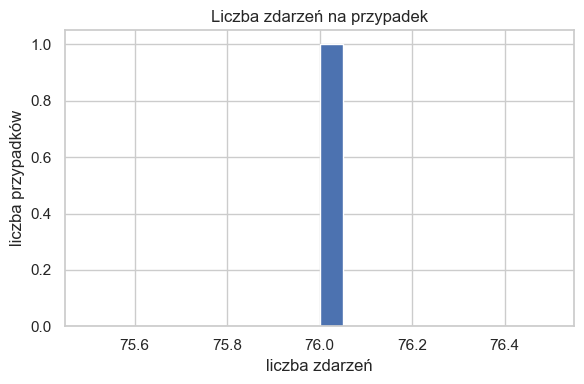

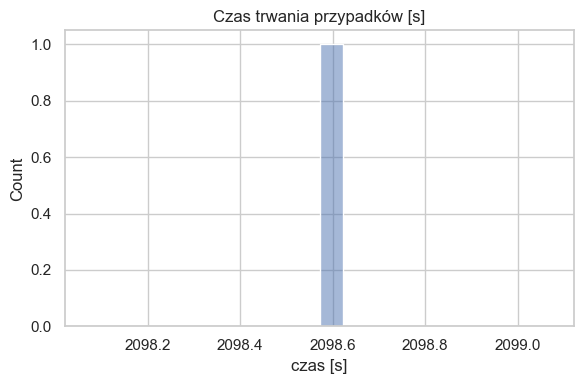

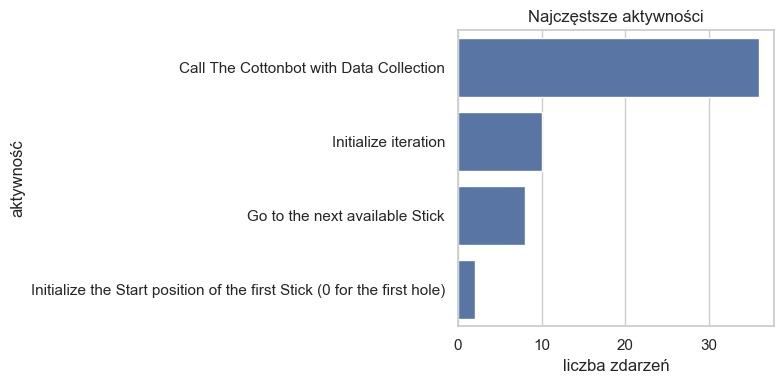

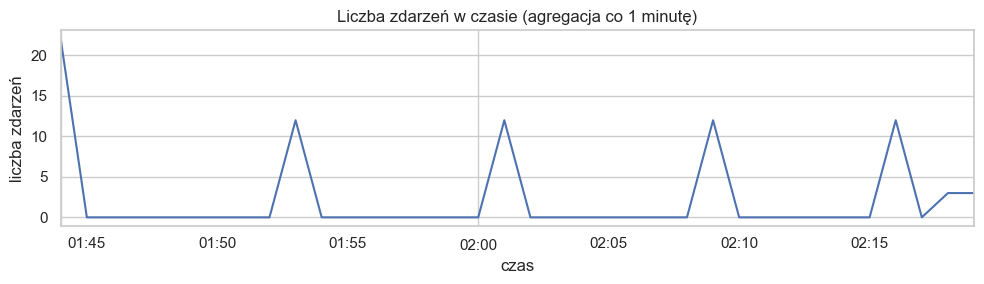

: 

In [ ]:
sns.set(style="whitegrid")

# Histogram liczby zdarzeń na przypadek
if "case_id" in df_events.columns:
    plt.figure(figsize=(6, 4))
    events_per_case.plot(kind="hist", bins=20)
    plt.title("Liczba zdarzeń na przypadek")
    plt.xlabel("liczba zdarzeń")
    plt.ylabel("liczba przypadków")
    plt.tight_layout()
    plt.show()

# Rozkład czasu trwania przypadków
if "case_id" in df_events.columns and "timestamp" in df_events.columns:
    plt.figure(figsize=(6, 4))
    sns.histplot(case_durations["duration_sec"].dropna(), bins=20, kde=True)
    plt.title("Czas trwania przypadków [s]")
    plt.xlabel("czas [s]")
    plt.tight_layout()
    plt.show()

# Częstość aktywności
if "activity" in df_events.columns:
    plt.figure(figsize=(8, 4))
    activity_counts = df_events["activity"].value_counts().head(30)
    sns.barplot(x=activity_counts.values, y=activity_counts.index, orient="h")
    plt.title("Najczęstsze aktywności")
    plt.xlabel("liczba zdarzeń")
    plt.ylabel("aktywność")
    plt.tight_layout()
    plt.show()

# Timeline – liczba zdarzeń w czasie (agregacja minutowa)
if "timestamp" in df_events.columns:
    tmp = df_events.dropna(subset=["timestamp"]).set_index("timestamp")
    events_over_time = tmp.resample("1min").size()
    plt.figure(figsize=(10, 3))
    events_over_time.plot()
    plt.title("Liczba zdarzeń w czasie (agregacja co 1 minutę)")
    plt.xlabel("czas")
    plt.ylabel("liczba zdarzeń")
    plt.tight_layout()
    plt.show()

## 7. Pełna analiza całego zapisanego procesu (wszystkie pliki `*.xes.yaml`)



Poniższa sekcja realizuje Milestone 1 na pełnym zbiorze danych (`cotton-candy/batch-*/*.xes.yaml`) i obejmuje:

- opis kontekstu + liczby przypadków/zdarzeń,

- identyfikację kluczowych atrybutów (`case id`, `activity`, `timestamp`, `resource`),

- analizę jakości danych (braki, duplikaty, niespójne timestampy i typy),

- EDA + statystyki podstawowe,

- wizualizacje typu timeline / distribution / frequency.

In [ ]:
# Pełna analiza całego procesu (streaming po wszystkich plikach .xes.yaml)
from collections import Counter, defaultdict
from urllib.parse import urlparse
import re

ISO_TZ_RE = re.compile(r"^\d{4}-\d{2}-\d{2}T\d{2}:\d{2}:\d{2}(?:\.\d+)?(?:Z|[+-]\d{2}:\d{2})$")
INTEREST_KEYS = {
    "concept:instance",
    "cpee:instance",
    "concept:name",
    "time:timestamp",
    "concept:endpoint",
    "id:id",
    "cpee:activity",
    "lifecycle:transition",
    "cpee:lifecycle:transition",
}

def classify_timestamp(value):
    if value is None or value == "":
        return "missing"
    if isinstance(value, str) and ISO_TZ_RE.match(value):
        return "iso8601_with_tz"
    if isinstance(value, str):
        return "other_string"
    return type(value).__name__

def normalize_resource(endpoint):
    if not endpoint:
        return None
    endpoint = endpoint.replace("https-get://", "https://").replace("https-post://", "https://")
    parsed = urlparse(endpoint)
    return parsed.netloc if parsed.netloc else endpoint

def parse_ts(raw):
    if raw is None or raw == "":
        return None
    ts = pd.to_datetime(raw, errors="coerce", utc=True)
    return None if pd.isna(ts) else ts

def stream_events(file_path):
    current = None
    seq = 0
    with file_path.open("r", encoding="utf-8") as f:
        for raw_line in f:
            line = raw_line.rstrip("\n")

            if line == "---":
                if current is not None:
                    yield current, seq
                current = None
                continue

            if line == "event:":
                current = {}
                seq += 1
                continue

            if current is None:
                continue

            if line.startswith("  ") and not line.startswith("    "):
                stripped = line.strip()
                if ": " in stripped:
                    key, value = stripped.split(": ", 1)
                elif stripped.endswith(":"):
                    key, value = stripped[:-1], ""
                else:
                    continue

                if key in INTEREST_KEYS and key not in current:
                    current[key] = value

    if current is not None:
        yield current, seq

all_xes_files = sorted((DATA_DIR).glob("batch-*/*.xes.yaml"))
print(f"Liczba plików cases (*.xes.yaml): {len(all_xes_files)}")

# Agregaty
total_events = 0
activity_counter = Counter()
timeline_hourly = Counter()

missing = Counter()
type_counts = {
    "case_id": Counter(),
    "case_uuid": Counter(),
    "activity": Counter(),
    "timestamp_raw": Counter(),
    "timestamp_class": Counter(),
}

duplicate_set = set()
duplicate_count = 0
parse_failed = 0
non_monotonic = 0

case_events = defaultdict(int)
case_min_ts = {}
case_max_ts = {}
case_prev_ts = {}

for i, path in enumerate(all_xes_files, start=1):
    fallback_case = str(path.relative_to(DATA_DIR)).replace("\\", "/")

    for event, seq in stream_events(path):
        total_events += 1

        case_id = event.get("concept:instance")
        case_uuid = event.get("cpee:instance")
        activity = event.get("concept:name") or event.get("id:id") or event.get("cpee:activity")
        ts_raw = event.get("time:timestamp")
        endpoint = event.get("concept:endpoint")
        resource = normalize_resource(endpoint)
        ts = parse_ts(ts_raw)
        ts_class = classify_timestamp(ts_raw)

        case_key = case_uuid or case_id or fallback_case

        # Braki
        if case_id in (None, ""):
            missing["case_id"] += 1
        if case_uuid in (None, ""):
            missing["case_uuid"] += 1
        if activity in (None, ""):
            missing["activity"] += 1
        if ts_raw in (None, ""):
            missing["timestamp_raw"] += 1
        if ts is None:
            missing["timestamp"] += 1
        if resource in (None, ""):
            missing["resource"] += 1

        # Typy
        type_counts["case_id"][type(case_id).__name__] += 1
        type_counts["case_uuid"][type(case_uuid).__name__] += 1
        type_counts["activity"][type(activity).__name__] += 1
        type_counts["timestamp_raw"][type(ts_raw).__name__] += 1
        type_counts["timestamp_class"][ts_class] += 1

        # Duplikaty
        dup_key = (
            case_id,
            case_uuid,
            activity,
            ts_raw,
            event.get("id:id"),
            endpoint,
            event.get("lifecycle:transition"),
            event.get("cpee:lifecycle:transition"),
        )
        if dup_key in duplicate_set:
            duplicate_count += 1
        else:
            duplicate_set.add(dup_key)

        # Jakość timestampów
        if ts_raw not in (None, "") and ts is None:
            parse_failed += 1

        if ts is not None:
            prev = case_prev_ts.get(case_key)
            if prev is not None and ts < prev:
                non_monotonic += 1
            case_prev_ts[case_key] = ts

            if case_key not in case_min_ts or ts < case_min_ts[case_key]:
                case_min_ts[case_key] = ts
            if case_key not in case_max_ts or ts > case_max_ts[case_key]:
                case_max_ts[case_key] = ts

            timeline_hourly[ts.floor("h")] += 1

        case_events[case_key] += 1
        activity_counter[activity if activity not in (None, "") else "<missing>"] += 1

    if i % 200 == 0:
        print(f"Przetworzono plików: {i}/{len(all_xes_files)}")

print("\n=== PODSUMOWANIE KONTEKSTU ===")
print({
    "liczba_plikow_cases": len(all_xes_files),
    "liczba_cases": len(case_events),
    "liczba_eventow": total_events,
    "liczba_activities": len(activity_counter),
})

print("\n=== KLUCZOWE ATRYBUTY (czy są) ===")
print({
    "case_id_present": True,
    "case_uuid_present": True,
    "activity_present": True,
    "timestamp_present": True,
    "resource_proxy_present": True,
})

print("\n=== JAKOŚĆ DANYCH ===")
print("Braki:", dict(missing))
print("Duplikaty:", duplicate_count)
print("Nieudane parsowanie timestamp:", parse_failed)
print("Ujemne różnice czasu w case:", non_monotonic)
print("Typy case_id:", dict(type_counts["case_id"]))
print("Typy activity:", dict(type_counts["activity"]))
print("Klasy timestamp:", dict(type_counts["timestamp_class"]))

# Statystyki
events_per_case = pd.Series(list(case_events.values()), name="events_per_case")
durations = []
for case_key in case_events.keys():
    if case_key in case_min_ts and case_key in case_max_ts:
        durations.append((case_max_ts[case_key] - case_min_ts[case_key]).total_seconds())
durations_series = pd.Series(durations, name="duration_sec")
activity_freq = pd.Series(activity_counter).sort_values(ascending=False)
timeline_series = pd.Series(timeline_hourly).sort_index()

print("\n=== PODSTAWOWE STATYSTYKI ===")
print("eventy:", total_events)
print("cases:", len(case_events))
print("activities:", len(activity_counter))
print("\nZdarzenia na case:")
print(events_per_case.describe())
if not durations_series.empty:
    print("\nCzas trwania case [s]:")
    print(durations_series.describe())

# Wizualizacje: timeline / distribution / frequency
sns.set(style="whitegrid")

plt.figure(figsize=(12, 4))
timeline_series.plot(color="#1f77b4")
plt.title("Timeline: liczba zdarzeń na godzinę (cały proces)")
plt.xlabel("czas")
plt.ylabel("liczba zdarzeń")
plt.tight_layout()
plt.show()

plt.figure(figsize=(8, 4))
sns.histplot(events_per_case, bins=40, kde=True, color="#2ca02c")
plt.title("Distribution: liczba zdarzeń na przypadek")
plt.xlabel("liczba zdarzeń")
plt.ylabel("liczba przypadków")
plt.tight_layout()
plt.show()

if not durations_series.empty:
    plt.figure(figsize=(8, 4))
    sns.histplot(durations_series, bins=40, kde=True, color="#ff7f0e")
    plt.title("Distribution: czas trwania przypadków [s]")
    plt.xlabel("czas [s]")
    plt.ylabel("liczba przypadków")
    plt.tight_layout()
    plt.show()

top20 = activity_freq.head(20)
plt.figure(figsize=(10, 7))
sns.barplot(x=top20.values, y=top20.index, orient="h", color="#9467bd")
plt.title("Frequency: Top 20 aktywności")
plt.xlabel("liczba zdarzeń")
plt.ylabel("aktywność")
plt.tight_layout()
plt.show()